Running CNN-1 (Adam, 10 Epochs)...
Epoch 1/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 65s 137ms/step - accuracy: 0.9507 - loss: 0.1643 - val_accuracy: 0.9850 - val_loss: 0.0432
Epoch 2/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 58s 123ms/step - accuracy: 0.9855 - loss: 0.0468 - val_accuracy: 0.9886 - val_loss: 0.0341
Epoch 3/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 57s 122ms/step - accuracy: 0.9894 - loss: 0.0336 - val_accuracy: 0.9869 - val_loss: 0.0390
Epoch 4/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 57s 121ms/step - accuracy: 0.9925 - loss: 0.0230 - val_accuracy: 0.9879 - val_loss: 0.0405
Epoch 5/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 61s 131ms/step - accuracy: 0.9943 - loss: 0.0175 - val_accuracy: 0.9898 - val_loss: 0.0329
Epoch 6/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 68s 144ms/step - accuracy: 0.9955 - loss: 0.0135 - val_accuracy: 0.9901 - val_loss: 0.0360
Epoch 7/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 63s 134ms/step - accuracy: 0.9958 - loss: 0.0124 - val_accuracy: 0.9898 - val_loss: 0.0343
Epoch 8/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 63s 134m

/Users/bidhanroy/Desktop/Year3/Sem 6/BDA Lab/venv/lib/python3.13/site-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.8537 - loss: 0.5579 - val_accuracy: 0.9316 - val_loss: 0.2847
Epoch 2/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.9354 - loss: 0.2490 - val_accuracy: 0.9493 - val_loss: 0.1919
Epoch 3/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.9494 - loss: 0.1873 - val_accuracy: 0.9571 - val_loss: 0.1570
Epoch 4/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.9593 - loss: 0.1531 - val_accuracy: 0.9621 - val_loss: 0.1369
Epoch 5/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.9655 - loss: 0.1294 - val_accuracy: 0.9656 - val_loss: 0.1224
Epoch 6/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.9702 - loss: 0.1126 - val_accuracy: 0.9685 - val_loss: 0.1117
Epoch 7/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - accuracy: 0.9736 - loss: 0.0995 - val_accuracy: 0.9695 - val_loss: 0.1036
Epoch 8/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.9772 - loss: 0.0879 - val_accuracy: 0.

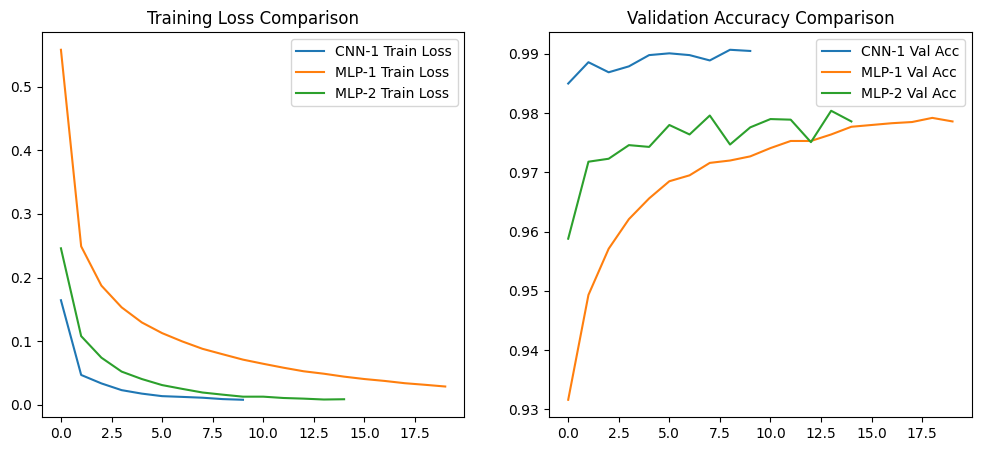


Comparison Table:
Model    FC Layer Optimizer  Epochs  Accuracy
CNN-1         128      Adam      10    0.9905
MLP-1 512-256-128       SGD      20    0.9786
MLP-2         256      Adam      15    0.9786


In [1]:
import tensorflow as tf
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt
import pandas as pd

(x_train, y_train), (x_test, y_test) = tf.keras.datasets.mnist.load_data()
x_train, x_test = x_train[..., None] / 255.0, x_test[..., None] / 255.0

def get_cnn_1():
    model = models.Sequential([
        layers.Input(shape=(28, 28, 1)),
        layers.Conv2D(32, (3, 3), activation='relu'),
        layers.Conv2D(64, (3, 3), activation='relu'),
        layers.MaxPooling2D((2, 2)),
        layers.Dropout(0.25),
        layers.Flatten(),
        layers.Dense(128, activation='relu'),
        layers.Dense(10, activation='softmax')
    ])
    model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    return model

def get_mlp_1():
    model = models.Sequential([
        layers.Flatten(input_shape=(28, 28, 1)),
        layers.Dense(512),
        layers.BatchNormalization(),
        layers.Activation('relu'),
        layers.Dense(256),
        layers.BatchNormalization(),
        layers.Activation('relu'),
        layers.Dense(128),
        layers.BatchNormalization(),
        layers.Activation('relu'),
        layers.Dense(10, activation='softmax')
    ])
    model.compile(optimizer='sgd', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    return model

def get_mlp_2():
    model = models.Sequential([
        layers.Flatten(input_shape=(28, 28, 1)),
        layers.Dense(256),
        layers.BatchNormalization(),
        layers.Activation('relu'),
        layers.Dense(10, activation='softmax')
    ])
    model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    return model

results = []

print("Running CNN-1 (Adam, 10 Epochs)...")
cnn1 = get_cnn_1()
hist_cnn1 = cnn1.fit(x_train, y_train, epochs=10, batch_size=128, validation_data=(x_test, y_test))
results.append(["CNN-1", "128", "Adam", 10, hist_cnn1.history['val_accuracy'][-1]])

print("Running MLP-1 (SGD, 20 Epochs)...")
mlp1 = get_mlp_1()
hist_mlp1 = mlp1.fit(x_train, y_train, epochs=20, batch_size=128, validation_data=(x_test, y_test))
results.append(["MLP-1", "512-256-128", "SGD", 20, hist_mlp1.history['val_accuracy'][-1]])

print("Running MLP-2 (Adam, 15 Epochs)...")
mlp2 = get_mlp_2()
hist_mlp2 = mlp2.fit(x_train, y_train, epochs=15, batch_size=128, validation_data=(x_test, y_test))
results.append(["MLP-2", "256", "Adam", 15, hist_mlp2.history['val_accuracy'][-1]])

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(hist_cnn1.history['loss'], label='CNN-1 Train Loss')
plt.plot(hist_mlp1.history['loss'], label='MLP-1 Train Loss')
plt.plot(hist_mlp2.history['loss'], label='MLP-2 Train Loss')
plt.title('Training Loss Comparison')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(hist_cnn1.history['val_accuracy'], label='CNN-1 Val Acc')
plt.plot(hist_mlp1.history['val_accuracy'], label='MLP-1 Val Acc')
plt.plot(hist_mlp2.history['val_accuracy'], label='MLP-2 Val Acc')
plt.title('Validation Accuracy Comparison')
plt.legend()
plt.show()

df = pd.DataFrame(results, columns=["Model", "FC Layer", "Optimizer", "Epochs", "Accuracy"])
print("\nComparison Table:")
print(df.to_string(index=False))